https://colab.research.google.com/drive/1h29Y2CQR5F71nuDxn430-818N7CsERKt#scrollTo=IpCxFhxdERSr

In [ ]:
import torch
import torch.nn as nn
import json
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST
# from clearml import Task, Logger
import matplotlib.pyplot as plt

In [ ]:
# with open("creds.json", "r") as lines:
#     creds = json.load(lines)

# Task.set_credentials(
#     api_host=creds["api_server"],
#     web_host=creds["web_server"],
#     files_host=creds["files_server"],
#     key=creds["access_key"],
#     secret=creds["secret_key"]
# )

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# dataset = MNIST(root='./data', train=True, download=True, transform=transform)
# train_size = int(0.8 * len(dataset))
# val_size   = len(dataset) - train_size

train_dataset = FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = FashionMNIST(root='./data', train=False, download=True, transform=transform)

# train_data, val_data = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader   = DataLoader(test_dataset,   batch_size=1000, shuffle=False)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 207kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.86MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.2MB/s]


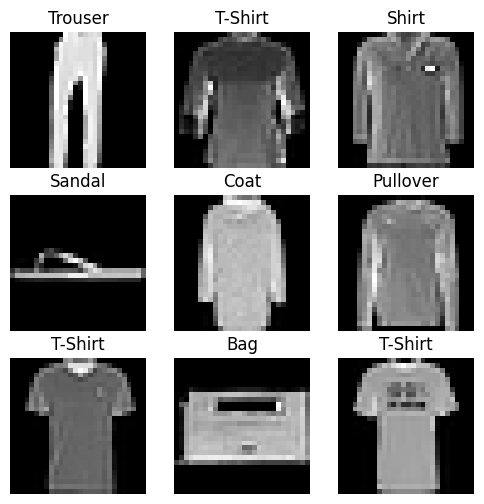

In [ ]:
dataset = FashionMNIST(root='./data', train=True, download=False, transform=transforms.ToTensor())
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(dataset), size=(1,)).item()
    img, label = dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [ ]:
# Название модели для отображения графиков и логирования
name = 'MLP_3layer_256_128_64'
# Последовательность самой модели
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 32),
    nn.LeakyReLU(0.01),
    nn.Linear(32, 10)
)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')

def init_model(m):
    if isinstance(m, (nn.Linear, nn.Conv2d)):
        nn.init.kaiming_normal_(
            m.weight,
            nonlinearity='leaky_relu',
            a=0.01
        )
        if m.bias is not None:
            nn.init.zeros_(m.bias)

print(model.apply(init_model))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Модель перенесена на девайс: {device}")


# task = Task.init(project_name='NeuralNetworkCourse',
#                  task_name=name,
#                  reuse_last_task_id=False)
# logger = Logger.current_logger()

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=32, bias=True)
  (2): LeakyReLU(negative_slope=0.01)
  (3): Linear(in_features=32, out_features=10, bias=True)
)
Модель перенесена на девайс: cuda


In [ ]:
param_cnt_list = [layer.numel() for layer in model.parameters()]
print(param_cnt_list)
print(sum(param_cnt_list))


[25088, 32, 320, 10]
25450


In [ ]:
print(torch.cuda.is_available())
if torch.cuda.is_available():
  print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
%%time
num_epochs = 50
hist = {name: {'train_loss': [], 'val_loss': [], 'val_acc': [], 'lr': []} }
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for epoch in range(1, num_epochs + 1):
    # Обучение
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
      images = images.to(device)
      labels = labels.to(device)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()
      running_loss += loss.item()
    epoch_train_loss = running_loss / len(train_loader)
    # Добавляем потерю для графика
    hist[name]['train_loss'].append(epoch_train_loss)

    # Валидация
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
      for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        val_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    # В этот раз посчитаем валидацию на каждой эпохе обучения
    epoch_val_loss = val_loss / len(test_loader)
    epoch_val_acc  = 100.0 * correct / total
    hist[name]['val_loss'].append(epoch_val_loss)
    hist[name]['val_acc'].append(epoch_val_acc)

    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    hist[name]['lr'].append(current_lr)

    # # Логирование в ClearML
    # logger.report_scalar("Loss", "Train", epoch_train_loss, epoch)
    # logger.report_scalar("Loss", "Validation", epoch_val_loss, epoch)
    # logger.report_scalar("Accuracy", "Validation", epoch_val_acc, epoch)

    print(f"{name} Epoch {epoch}/{num_epochs} - "
            f"Train Loss: {epoch_train_loss:.4f}, "
            f"Val Loss: {epoch_val_loss:.4f}, "
            f"Val Acc: {epoch_val_acc:.2f}%, "
            f"LR: {current_lr:.4f}"
    )

# task.close()
# task.get_output_log_web_page()

MLP_3layer_256_128_64 Epoch 1/50 - Train Loss: 0.2688, Val Loss: 0.3694, Val Acc: 87.00%LR: 0.0010
MLP_3layer_256_128_64 Epoch 2/50 - Train Loss: 0.2628, Val Loss: 0.3918, Val Acc: 86.73%LR: 0.0010
MLP_3layer_256_128_64 Epoch 3/50 - Train Loss: 0.2562, Val Loss: 0.3625, Val Acc: 87.13%LR: 0.0010
MLP_3layer_256_128_64 Epoch 4/50 - Train Loss: 0.2525, Val Loss: 0.3893, Val Acc: 86.74%LR: 0.0010
MLP_3layer_256_128_64 Epoch 5/50 - Train Loss: 0.2484, Val Loss: 0.3623, Val Acc: 87.66%LR: 0.0010
MLP_3layer_256_128_64 Epoch 6/50 - Train Loss: 0.2436, Val Loss: 0.3732, Val Acc: 86.99%LR: 0.0010
MLP_3layer_256_128_64 Epoch 7/50 - Train Loss: 0.2424, Val Loss: 0.3702, Val Acc: 87.10%LR: 0.0010
MLP_3layer_256_128_64 Epoch 8/50 - Train Loss: 0.2378, Val Loss: 0.4052, Val Acc: 86.76%LR: 0.0010
MLP_3layer_256_128_64 Epoch 9/50 - Train Loss: 0.2338, Val Loss: 0.3733, Val Acc: 87.24%LR: 0.0010
MLP_3layer_256_128_64 Epoch 10/50 - Train Loss: 0.2330, Val Loss: 0.3753, Val Acc: 87.63%LR: 0.0010
MLP_3laye

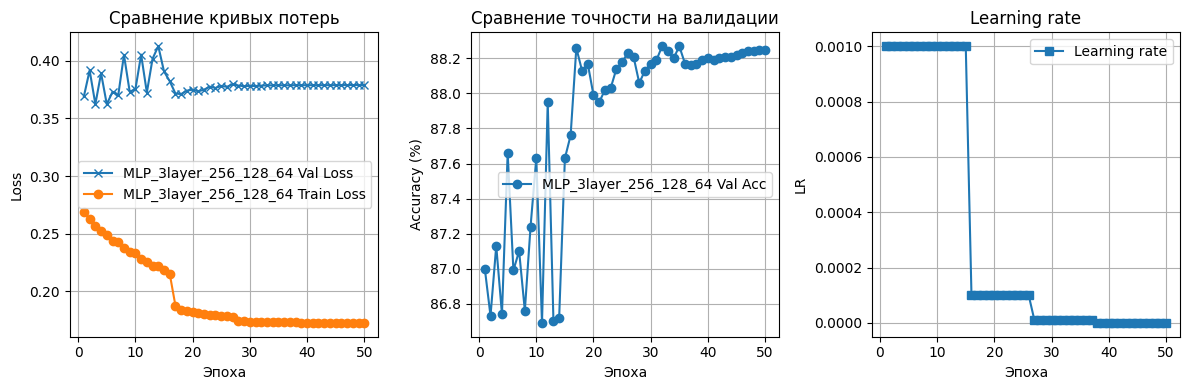

In [ ]:
# Визуализация истории обучения (пример для loss)
plt.figure(figsize=(12, 4))


# Потеря
plt.subplot(1, 3, 1)
epochs = range(1, num_epochs + 1)
plt.plot(epochs, hist[name]['val_loss'],   marker='x', label=f"{name} Val Loss")
plt.plot(epochs, hist[name]['train_loss'], marker='o', label=f"{name} Train Loss",)
plt.title("Сравнение кривых потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)


# Точность
plt.subplot(1, 3, 2)
epochs = range(1, num_epochs + 1)
plt.plot(epochs, hist[name]['val_acc'], marker='o', label=f"{name} Val Acc")
plt.title("Сравнение точности на валидации")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

# Точность
plt.subplot(1, 3, 3)
epochs = range(1, num_epochs + 1)
plt.plot(epochs, hist[name]['lr'], marker='s', label=f"Learning rate")
plt.title("Learning rate")
plt.xlabel("Эпоха")
plt.ylabel("LR")
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()
